In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mp
import seaborn as sn
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [2]:
df=pd.read_csv('auto-mpg.csv')
df=pd.DataFrame(df)
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB


In [4]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
df['horsepower'].unique()

<ArrowStringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
   '?', '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: str

In [6]:
df.shape

(398, 9)

In [7]:
df['horsepower']=df['horsepower'].replace('?',pd.NA)

In [8]:
df.dropna(inplace=True)

In [9]:
df['horsepower']=df['horsepower'].astype(float)

In [10]:
df['horsepower'].dtype

dtype('float64')

In [36]:
df.drop('car name',axis=1,inplace=True)

In [37]:
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1


In [ ]:
mp.figure(figsize=(10,7))
sn.heatmap(df.corr(),annot=True,cmap="coolwarm")

In [ ]:
df.hist(bins=20, figsize=(12, 8))

In [ ]:
sn.barplot(data=df,x='model_year',y='horsepower')

In [ ]:
sn.barplot(data=df,x='cylinders',y='mpg')

In [ ]:
sn.barplot(data=df,x='cylinders',y='horsepower')

In [ ]:
sn.barplot(data=df,x='cylinders',y='displacement')

In [ ]:
sn.barplot(data=df,x='origin',y='horsepower')

In [ ]:
sn.barplot(data=df,x='origin',y='weight')

<Axes: xlabel='origin', ylabel='cylinders'>

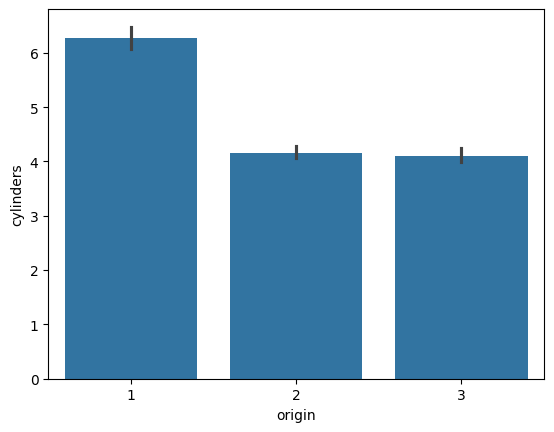

In [16]:
sn.barplot(data=df,x='origin',y='cylinders')

In [14]:
x=df.drop(['mpg','car name'],axis=1)
y=df['mpg']

In [15]:
print(f"The shape of the x is {x.shape}")
print(f"The shape of the y is {y.shape}")

The shape of the x is (392, 7)
The shape of the y is (392,)


In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
print(f"The shape of the x_train is {x_train.shape}")
print(f"The shape of the x_test is {x_test.shape}")
print(f"The shape of the y_train is {y_train.shape}")
print(f"The shape of the y-test is {y_test.shape}")

The shape of the x_train is (313, 7)
The shape of the x_test is (79, 7)
The shape of the y_train is (313,)
The shape of the y-test is (79,)


In [19]:
sc=StandardScaler()
xtrain_scl=sc.fit_transform(x_train)
xtest_scl=sc.transform(x_test)



In [20]:
xtrain_scl.shape[1]

7

In [21]:
from keras.layers import BatchNormalization
mdl=Sequential()
mdl.add(Dense(64,activation='relu',input_dim=7))
mdl.add(BatchNormalization())
mdl.add(Dense(32,activation='relu'))
mdl.add(BatchNormalization())
mdl.add(Dense(16,activation='relu'))
mdl.add(BatchNormalization())
mdl.add(Dense(1,activation='linear'))

D:\Python 311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
mdl.compile(loss='mean_squared_error',optimizer='Adam',metrics=['accuracy'])

In [23]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [24]:
hist=mdl.fit(xtrain_scl,y_train,epochs=177,batch_size=32,validation_split=0.2)

Epoch 1/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.0000e+00 - loss: 605.7925 - val_accuracy: 0.0000e+00 - val_loss: 676.8873
Epoch 2/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0000e+00 - loss: 583.9657 - val_accuracy: 0.0000e+00 - val_loss: 670.4081
Epoch 3/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0000e+00 - loss: 572.1386 - val_accuracy: 0.0000e+00 - val_loss: 664.4456
Epoch 4/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 565.4656 - val_accuracy: 0.0000e+00 - val_loss: 659.1940
Epoch 5/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0000e+00 - loss: 561.0451 - val_accuracy: 0.0000e+00 - val_loss: 653.8503
Epoch 6/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0000e+00 - loss: 555.1085 - val_accuracy: 0.0000e+00 - val_loss: 648.4282
Epoch 7/177
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0000e+00 - loss: 550.5102 - val_accuracy: 0.0000e+00 - val_loss: 642.8357
Epoch 8/177
8/8 ━━━━━━━━━━━━━━━━━━

In [25]:
mdl.evaluate(xtest_scl,y_test,verbose=0)

[7.735894680023193, 0.0]

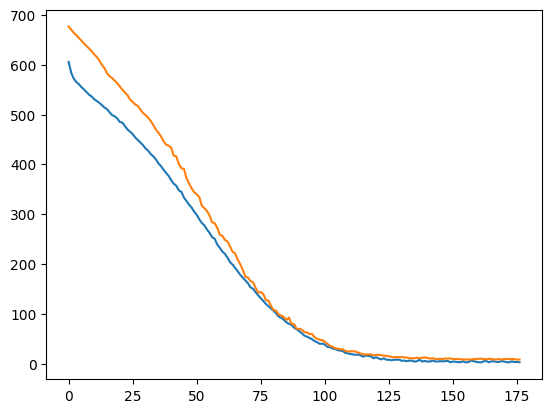

In [26]:
mp.plot(hist.history['loss'])
mp.plot(hist.history['val_loss'])

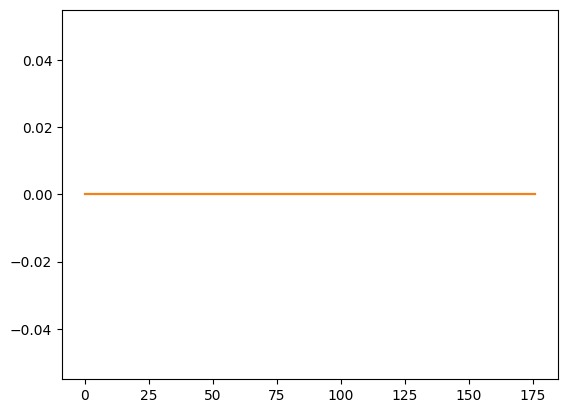

In [27]:
mp.plot(hist.history['accuracy'])
mp.plot(hist.history['val_accuracy'])


In [28]:
y_pred=mdl.predict(xtest_scl)
y_traip=mdl.predict(xtrain_scl)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [29]:
from sklearn.metrics import*

In [30]:
r2_sc=r2_score(y_test,y_pred)
print(f"The test r2_score of the model is :  {r2_score(y_test,y_pred)}")
print(f"The training r2_score of the model is :  {r2_score(y_train,y_traip)}")

The test r2_score of the model is :  0.8484363835036278
The training r2_score of the model is :  0.9602100590555905


In [31]:
mse_s=mean_squared_error(y_test,y_pred)
print(f"The mse of the model is : {mse_s}")

The mse of the model is : 7.73589538391812


In [33]:
import joblib
joblib.dump(mdl, 'model.pkl') # Random Forest Model
# joblib.dump(preprocessor, 'preprocessor.pkl') # OneHotEncoder
# joblib.dump(lr_model, 'linear_model.pkl') # Linear Regression bhi




print("Models saved")

Models saved
